In [1]:
import sys
from pathlib import Path
sys.path[:0] = [str(Path.cwd().parent)]

import numpy as np
import matplotlib.pyplot as plt

from scripts.hamiltonian import Lattice, Hamiltonian
from scripts.self_consistency import bdg_sc

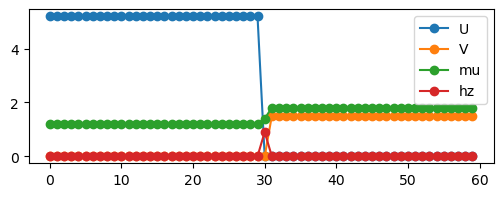

In [2]:
widthS = 30
widthF = 1
widthP = 30

X, Y = widthS+widthP, 61
lattice = Lattice(X, Y)
t = 1
T = 0.01

muS = 1.2 * t
muP = 1.8 * t
muF = 1.4 * t
mu = np.zeros(lattice.X)
mu[:widthS] = muS
mu[widthS:widthS + widthF] = muF
mu[widthS + widthF:widthS + widthF + widthP] = muP

hz0 = 0.9 * t
hz = np.zeros_like(mu)
hz[widthS:widthS + widthF] = hz0

U0 = 5.2 * t
U = U0 * np.ones(lattice.X)
U[widthS:] = 0
# U[widthS-1] = U0/2

V0 = 1.5 * t
V = V0 * np.ones(lattice.X)
V[:widthF+widthS] = 0 
# V[widthF+widthS] = V0/2

V_prime = None

plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(U, '-o', label="U")
if V is not None:
    plt.plot(V, '-o', label="V")
if V_prime is not None:
    plt.plot(V_prime, '-o', label="V'",)
plt.plot(mu, '-o', label='mu')
plt.plot(hz, '-o', label='hz')

plt.legend()

In [3]:
H = Hamiltonian(t, mu, lattice, U=U, V_prime=V_prime, V=V,
                F_init=[0.1, -0.1, 0.1j, -0.1j],
                hz=hz, F0_init=0.1)
                
                # Fuu_init=[0.01, -0.01, 0.01j, -0.01j],
                # Fdd_init=[0.01, -0.01, 0.01j, -0.01j])#, F0_init=0.1)


d:\miniconda3\envs\master-venv\lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\miniconda3\envs\master-venv\lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


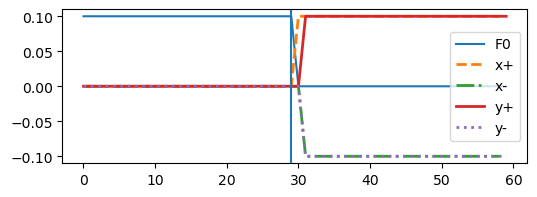

In [4]:
plt.figure(figsize=(6,2))
if U is not None:
    plt.plot(H.F0, label="F0")
if V is not None:
    plt.plot(np.real(H.F_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.F_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.imag(H.F_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.imag(H.F_ymin), label="y-", linestyle=':', lw=2)
if V_prime is not None:
    plt.plot(np.real(H.Fuu_xplus), label="x+", linestyle='--', lw=2)
    plt.plot(np.real(H.Fuu_xmin), label="x-", linestyle='-.', lw=2)
    plt.plot(np.imag(H.Fuu_yplus), label="y+", linestyle='-', lw=2)
    plt.plot(np.imag(H.Fuu_ymin), label="y-", linestyle=':', lw=2)
plt.legend()
plt.axvline(widthS-1)

In [5]:
F_swave, F_dwave, F_px, F_py = bdg_sc(H, atol=1e-6, rtol=1e-3, maxiter=500, verbose=False, temperature=T)

Converged after 146 iterations


In [6]:
F_yplus = H.Fuu_yplus + H.Fdd_yplus 
F_ymin = H.Fuu_ymin + H.Fdd_ymin
F_xplus = np.zeros_like(F_yplus)
F_xmin = np.zeros_like(F_yplus)
F_xplus[:-1] = H.Fuu_xplus + H.Fdd_xplus
F_xmin[1:]  = H.Fuu_xmin + H.Fdd_xmin

F0 = H.F0

F_swave2 = (F_xplus + F_xmin + F_yplus + F_ymin) / 4
F_dwave2 = (F_xplus + F_xmin - F_yplus - F_ymin) / 4
F_px2 = (F_xplus - F_xmin) / 2
F_py2 = (F_yplus - F_ymin) / 2

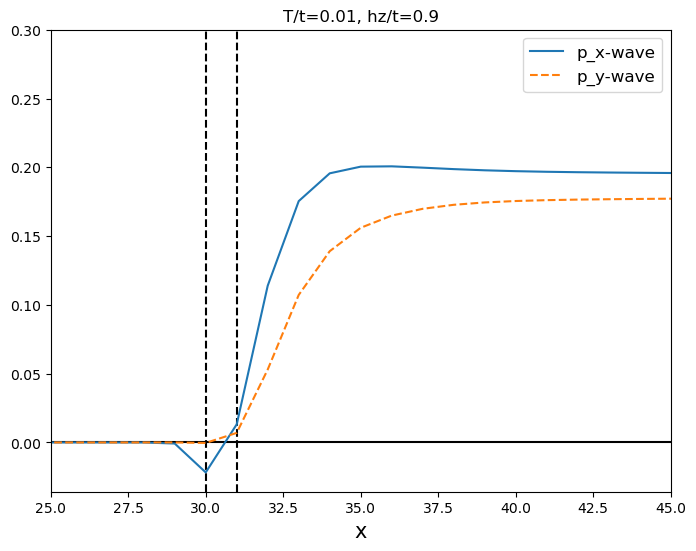

In [7]:
x = np.arange(1, widthS + widthP + 1)

fig, axs = plt.subplots(1, 1, figsize=(8, 6))
axs.set_title(f"T/t={T}, hz/t={hz0}")

axs.axhline(0, color = 'black')
# axs.axhline(0.2, color = 'black')

axs.axvline(widthS, color='black', linestyle='--')
axs.axvline(widthS+widthF, color='black', linestyle='--')

axs.plot(x, np.real(F_px), label="p_x-wave")
axs.plot(x, np.imag(F_py), "--", label="p_y-wave")
axs.set_xlabel("x", fontsize=15)
axs.set_xlim(25, 45)
axs.set_ylim(None, 0.3)
axs.legend(fontsize=12, loc="best")
plt.savefig('../figures/SFP.pdf')
plt.show()

# IMPORTANT: Test phase for SFP